# Construction Safety Monitor

**Model:** YOLOv8s  
**Task:** PPE compliance detection  
**Dataset:** Roboflow Construction Safety Dataset (downloaded manually) + our own site photos

### Classes
| ID | Class | Safe? |
|----|-------|-------|
| 0 | `hardhat` | Safe |
| 1 | `no_hardhat` | VIOLATION |
| 2 | `vest` | Safe |
| 3 | `no_vest` | VIOLATION |
| 4 | `person` | Neutral |



In [2]:
import os
import zipfile
from google.colab import files

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
DATASET_DIR = '/content/dataset'

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(DATASET_DIR)

print(f'Extracted to: {DATASET_DIR}')

# find the data.yaml (it might be nested inside a subfolder)
DATA_YAML = None
for root, dirs, fnames in os.walk(DATASET_DIR):
    for fname in fnames:
        if fname == 'data.yaml':
            DATA_YAML = os.path.join(root, fname)
            DATASET_DIR = root  # reset to wherever data.yaml lives
            break

if DATA_YAML is None:
    raise FileNotFoundError('data.yaml not found. Make sure you downloaded YOLOv8 format from Roboflow.')

print(f'data.yaml found at: {DATA_YAML}')

Saving Construction Site Safety.v30-raw-images_latestversion.yolov8.zip to Construction Site Safety.v30-raw-images_latestversion.yolov8.zip
Extracted to: /content/dataset
data.yaml found at: /content/dataset/data.yaml


In [3]:
import yaml
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
print(cfg['names'])
print('Total classes:', cfg['nc'])

['Excavator', 'Gloves', 'Hardhat', 'Ladder', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'SUV', 'Safety Cone', 'Safety Vest', 'bus', 'dump truck', 'fire hydrant', 'machinery', 'mini-van', 'sedan', 'semi', 'trailer', 'truck and trailer', 'truck', 'van', 'vehicle', 'wheel loader']
Total classes: 25


In [4]:
import yaml

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

print('Classes:', cfg['names'])
print('Num classes:', cfg['nc'])

# fix paths in data.yaml to point to absolute paths so YOLO can find them
cfg['train'] = os.path.join(DATASET_DIR, 'train', 'images')
cfg['val']   = os.path.join(DATASET_DIR, 'valid', 'images')
cfg['test']  = os.path.join(DATASET_DIR, 'test',  'images')

with open(DATA_YAML, 'w') as f:
    yaml.dump(cfg, f)

print('data.yaml updated with absolute paths.')

Classes: ['Excavator', 'Gloves', 'Hardhat', 'Ladder', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'SUV', 'Safety Cone', 'Safety Vest', 'bus', 'dump truck', 'fire hydrant', 'machinery', 'mini-van', 'sedan', 'semi', 'trailer', 'truck and trailer', 'truck', 'van', 'vehicle', 'wheel loader']
Num classes: 25
data.yaml updated with absolute paths.


## 2. Add Your Own Site Photos

**The label file format** (one line per object in the image):
```
class_id  center_x  center_y  width  height
```

**If you don't have your photos ready yet**, you can skip this cell and come back to it. The rest of the notebook will still run on the Roboflow data alone.

In [5]:
import shutil
import glob

TRAIN_IMG_DIR = os.path.join(DATASET_DIR, 'train', 'images')
TRAIN_LBL_DIR = os.path.join(DATASET_DIR, 'train', 'labels')

print('Select a zip containing your annotated photos and their .txt label files...')
print('(Each image must have a matching .txt file with the same name)')
print()

custom_upload = files.upload()
custom_zip = list(custom_upload.keys())[0]

CUSTOM_TMP = '/content/custom_tmp'
os.makedirs(CUSTOM_TMP, exist_ok=True)

with zipfile.ZipFile(custom_zip, 'r') as z:
    z.extractall(CUSTOM_TMP)

# collect all images and labels from the extracted folder
custom_images = glob.glob(os.path.join(CUSTOM_TMP, '**', '*.jpg'), recursive=True)
custom_images += glob.glob(os.path.join(CUSTOM_TMP, '**', '*.jpeg'), recursive=True)
custom_images += glob.glob(os.path.join(CUSTOM_TMP, '**', '*.png'), recursive=True)

copied_images = 0
copied_labels = 0
skipped = 0

for img_path in custom_images:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(os.path.dirname(img_path), stem + '.txt')

    if not os.path.exists(lbl_path):
        # also check if label is in a sibling 'labels' folder
        alt_lbl = img_path.replace('images', 'labels').replace(
            os.path.splitext(img_path)[1], '.txt'
        )
        if os.path.exists(alt_lbl):
            lbl_path = alt_lbl
        else:
            print(f'  skipping {os.path.basename(img_path)} - no matching label file found')
            skipped += 1
            continue

    dest_img = os.path.join(TRAIN_IMG_DIR, 'custom_' + os.path.basename(img_path))
    dest_lbl = os.path.join(TRAIN_LBL_DIR, 'custom_' + stem + '.txt')

    shutil.copy(img_path, dest_img)
    shutil.copy(lbl_path, dest_lbl)
    copied_images += 1
    copied_labels += 1

print(f'Added {copied_images} custom images to training set')
if skipped > 0:
    print(f'Skipped {skipped} images (no label file found)')
print(f'Total training images now: {len(glob.glob(os.path.join(TRAIN_IMG_DIR, "*")))}')

Select a zip containing your annotated photos and their .txt label files...
(Each image must have a matching .txt file with the same name)



Saving labels_my-project-name_2026-04-01-08-34-08 2.zip to labels_my-project-name_2026-04-01-08-34-08 2.zip
  skipping Site_image42.jpeg - no matching label file found
  skipping Site_image64.jpeg - no matching label file found
Added 65 custom images to training set
Skipped 2 images (no label file found)
Total training images now: 586


## 3. Dataset Exploration

In [6]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

class_names = cfg['names']

train_images = glob.glob(os.path.join(DATASET_DIR, 'train', 'images', '*'))
val_images   = glob.glob(os.path.join(DATASET_DIR, 'valid', 'images', '*'))
test_images  = glob.glob(os.path.join(DATASET_DIR, 'test',  'images', '*'))

print(f'Train : {len(train_images)}')
print(f'Val   : {len(val_images)}')
print(f'Test  : {len(test_images)}')
print(f'Total : {len(train_images)+len(val_images)+len(test_images)}')

# how many of the training images came from us
custom_count = len([p for p in train_images if 'custom_' in os.path.basename(p)])
print(f'\nOf which {custom_count} are our own site photos')

Train : 586
Val   : 114
Test  : 82
Total : 782

Of which 65 are our own site photos


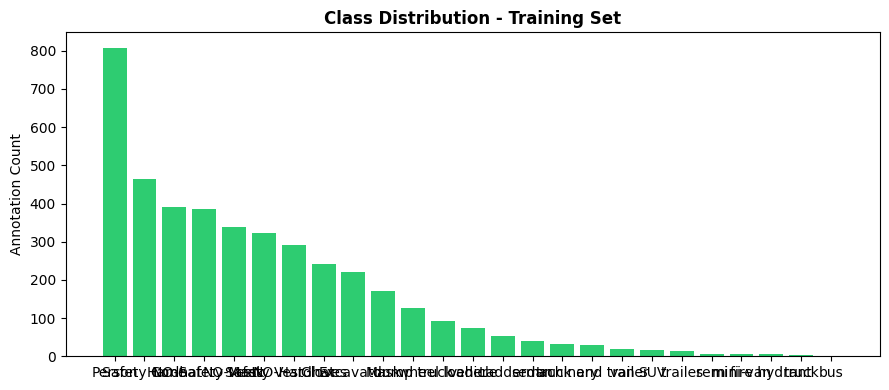

{'Person': 808, 'Safety Cone': 464, 'Hardhat': 392, 'NO-Safety Vest': 386, 'NO-Mask': 338, 'Safety Vest': 322, 'NO-Hardhat': 292, 'Gloves': 242, 'Excavator': 220, 'Mask': 170, 'dump truck': 127, 'wheel loader': 93, 'vehicle': 74, 'Ladder': 54, 'sedan': 39, 'machinery': 31, 'truck and trailer': 29, 'van': 18, 'SUV': 16, 'trailer': 13, 'semi': 7, 'mini-van': 6, 'fire hydrant': 6, 'truck': 4, 'bus': 1}


In [7]:
# class distribution across the full training set
label_counts = Counter()
for lf in glob.glob(os.path.join(DATASET_DIR, 'train', 'labels', '*.txt')):
    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                label_counts[class_names[int(parts[0])]] += 1

fig, ax = plt.subplots(figsize=(9, 4))
names, counts = zip(*sorted(label_counts.items(), key=lambda x: -x[1]))
colors = ['#e74c3c' if 'no_' in n else '#2ecc71' for n in names]
ax.bar(names, counts, color=colors)
ax.set_title('Class Distribution - Training Set', fontweight='bold')
ax.set_ylabel('Annotation Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print(dict(zip(names, counts)))

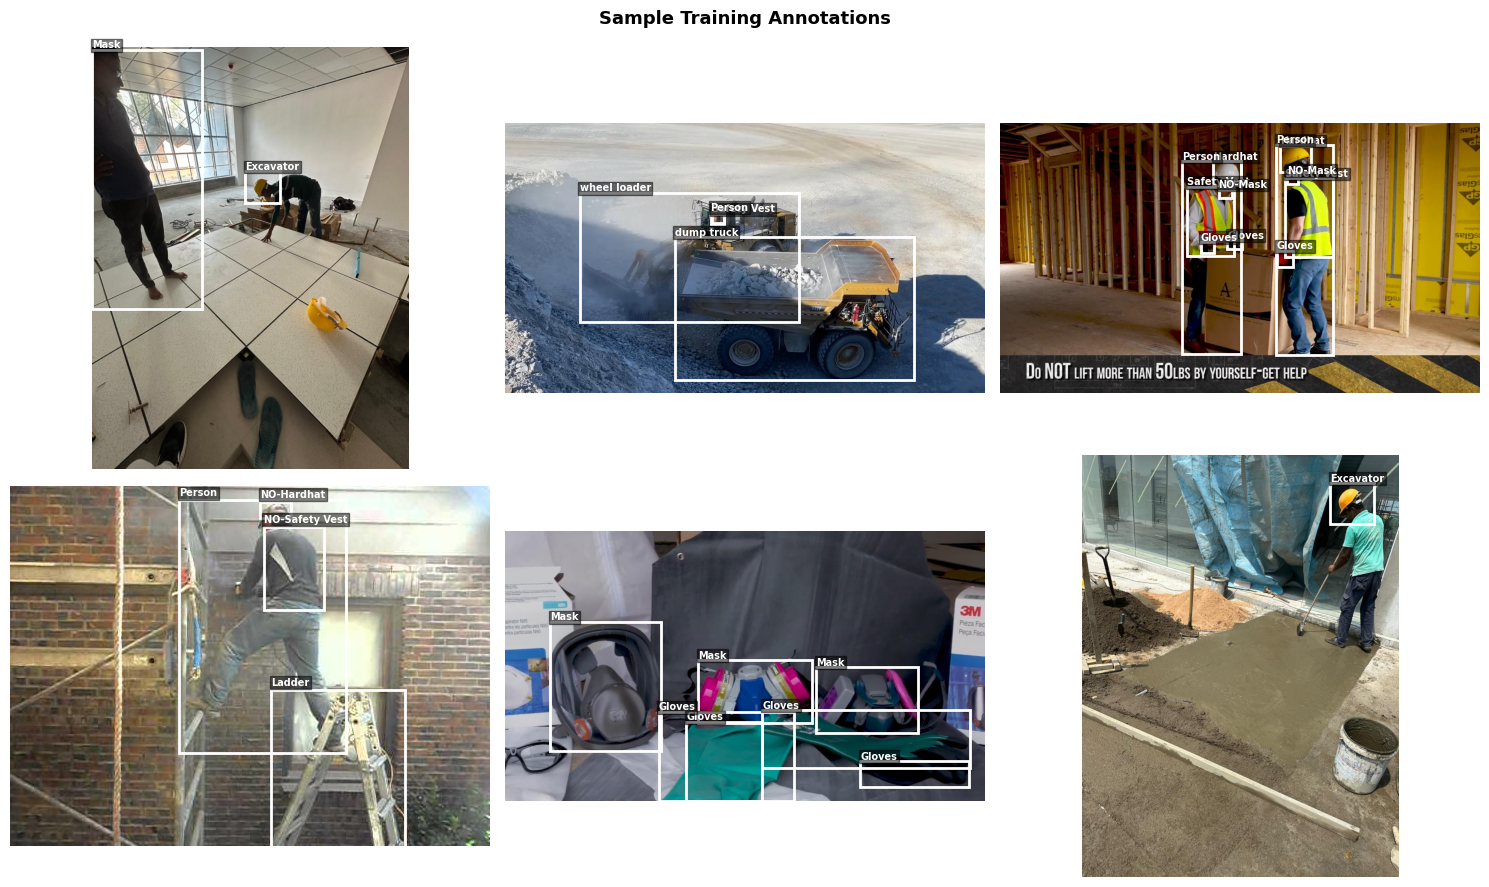

In [8]:
# visualise a sample of training annotations so we can sanity check labels
COLORS = {
    'hardhat':    '#2ecc71',
    'no_hardhat': '#e74c3c',
    'vest':       '#3498db',
    'no_vest':    '#e67e22',
    'person':     '#9b59b6'
}

samples = random.sample(train_images, min(6, len(train_images)))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, img_path in zip(axes.flat, samples):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    lbl  = os.path.join(DATASET_DIR, 'train', 'labels', stem + '.txt')
    img  = Image.open(img_path).convert('RGB')
    w, h = img.size
    ax.imshow(img)
    if os.path.exists(lbl):
        for line in open(lbl):
            parts = line.strip().split()
            if not parts:
                continue
            cls, cx, cy, bw, bh = map(float, parts)
            name  = class_names[int(cls)]
            color = COLORS.get(name, 'white')
            x1, y1 = (cx-bw/2)*w, (cy-bh/2)*h
            ax.add_patch(patches.Rectangle(
                (x1, y1), bw*w, bh*h,
                linewidth=2, edgecolor=color, facecolor='none'
            ))
            ax.text(x1, y1-4, name, color=color, fontsize=7, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))
    ax.axis('off')

plt.suptitle('Sample Training Annotations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_annotations.png', dpi=150)
plt.show()